# Donor / Recipient Classification — Combined 3-Method Approach

Freemuxlet separates each multiplexed sample into two genotype groups (SNG-0 / SNG-1).
Three independent methods determine which group is Donor vs Recipient.

---

## Priority Order: Sex mismatch → TCR clones → Cell-type anchor

| Priority | Method | Evidence | Applies to |
|----------|--------|----------|------------|
| **1 — Sex mismatch** | Per-cell sex inferred from Y-genes (DDX3Y, EIF1AY) and XIST on **all cells** | Group with donor sex → Donor; group with recipient sex → Recipient | Sex-mismatched patients only (donor sex ≠ recipient sex) |
| **2 — TCR clone mapping** | MLR-mapped donor T cell clones matched to same patient only | Group containing clones → Donor | Samples with mapped donor clones |
| **3 — Cell-type anchor** | Epithelial / Fibroblast / Endothelial cells are host tissue-resident → Recipient | Group with ≥ 1.5% anchor cells → Recipient; other group → Donor | All samples |

---

## Key Parameters

### Freemuxlet quality filter
- `LLK_THRESHOLD = 10` — minimum LLK_diff (BEST.LLK − NEXT.LLK) for a high-confidence singlet; cells below this → **Unclassified**
- Doublets (DROPLET.TYPE = DBL) and ambiguous (AMB) → **Unclassified**

### Method A — Cell-type anchor
- `ANCHOR_CELL_TYPES = {Epithelial, Fibroblast, Endothelial}` — host tissue-resident cell types marking the Recipient group
- `ANCHOR_NOISE_PCT = 1.5%` — anchor cells below this fraction of a group are treated as freemuxlet misassignments and ignored
- If **both** groups have ≥ 1.5% anchor cells AND no TCR clones AND no Sex mismatch → sample is **Unclassified** (likely heavy doublet contamination)

### Method B — Sex mismatch
- Sex genes: Y-linked = DDX3Y, EIF1AY; X-linked = XIST
- Per-cell thresholds: Male = mean Y-genes > 0.2 AND XIST < 0.05; Female = mean Y-genes < 0.05 AND XIST > 0.2
- Applied to all cells (most reliable sex gene expression)
- `MIN_SEXED_CELLS = 2` — minimum sexed cells required in a group to trust its sex call
- Two-sided: both groups have ≥ 2 sexed cells → compare sex fractions with `SEX_STRICT_THRESHOLD = 0.75` or `SEX_DIRECTIONAL_THRESHOLD = 0.50`
- One-sided fallback: one group has ≥ 2 sexed cells, the other has < 2 → classify from the one group alone
- Only applied to sex-mismatched patients (donor sex ≠ recipient sex); same-sex transplants → N/A

### Method C — TCR clone mapping
- Source: `tcell_ann_concat_Tcell_only_Migration_mapped_un.h5ad` (MLR-mapped donor T cell clones)
- `MIN_TCR_CLONES = 1` — minimum mapped clones to assign a group as Donor
- `TCR_DOMINANCE = 2.0` — one group must have ≥ 2× the clones of the other to be called dominant
- Clones are matched **same patient only** (filtered by SampleID)

### Unclassified conditions (per cell)
- Freemuxlet doublet or ambiguous droplet
- LLK_diff ≤ 10 (low-confidence singlet)
- Cell belongs to a sample where **no method** could resolve the group AND the sample has no sex-mismatch info AND no TCR clones (UA03, UA11, UA30)
- Cell belongs to a sample where both groups have substantial anchor cells AND no TCR clones, indicating heavy doublet contamination (UA31)
- Cell belongs to a Normal Donor (ND) patient — all cells labeled **Recipient** (no transplant, single individual)

---

## Sex-mismatched patients (Method B applies)


| PatientID | Recipient sex | Donor sex | Samples |
|-----------|--------------|-----------|---------|
| C159 | Female | Male | RH07, RH08, RH09, RH10 |
| C157 | Female | Male | UA05, UA06, UA07, UA08 |
| C98  | Male   | Female | UA13, UA14, UA15 |
| R085 | Female | Male | UA19, UA20 |
| C160 | Female | Male | UA31, UA32, UA33 |
| C179 | Female | Male | UA34, UA35, UA36, UA37 |

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
PROJECT_ROOT = Path('../..')

ALL_CELLS_ANN_PATH    = PROJECT_ROOT / 'adata_file' / 'filtered_combined_annotated.h5ad'
DEMUX_DATA_DIR        = PROJECT_ROOT / 'demux_output'
TCELL_ANN_MAPPED_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_Tcell_only_Migration_mapped_un.h5ad'

FIGURES_SC_DIR = PROJECT_ROOT / 'Figures' / 'Single_cell_figures'
OUT_ADATA_PATH = PROJECT_ROOT / 'adata_file' / 'all_cells_donor_recipient_celltype.h5ad'
OUT_TCELL_ADATA_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_con_muxlet.h5ad'

FIGURES_SC_DIR.mkdir(parents=True, exist_ok=True)
print('Using demux dir:', DEMUX_DATA_DIR)

Using demux dir: ../../demux_output


## Load data

In [3]:
tcell_ann_concat = anndata.read_h5ad(ALL_CELLS_ANN_PATH)
print(tcell_ann_concat)
print('\ncell_type counts:')
print(tcell_ann_concat.obs['cell_type'].value_counts())

# Load MLR-mapped T cell data (for Method C)
tcell_mapped_adata = anndata.read_h5ad(TCELL_ANN_MAPPED_PATH)
mapped_obs = tcell_mapped_adata.obs[tcell_mapped_adata.obs['mapping'] == 'Mapped'].copy()

# Ensure SampleID column is available for same-patient TCR filtering
if 'SampleID' not in mapped_obs.columns:
    mapped_obs['SampleID'] = mapped_obs.index.str.split('_').str[0]

print(f'\nMLR-mapped donor T cells: {len(mapped_obs)}')
print(mapped_obs['SampleID'].value_counts().head(10))

AnnData object with n_obs × n_vars = 116347 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'DoT', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_0.15', 'Myeloid', 'NK', 'B Cells', 'T cells', 'DC', 'Macrophage', 'Monocyte', 'Endothelial', 'Fibroblast', 'NK cells', 'B cells', 'Plasma cells', 'Epithelial cells_6', 'Epithelial cell_9', 'Epithelial cell_10', 'Endothelial cell', 'Mast cell', 'cell_type'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'Pati

## Classification constants

In [4]:
# Method A — host tissue-resident anchor cell types
ANCHOR_CELL_TYPES = {'Epithelial', 'Fibroblast', 'Endothelial'}

# Method B — sex gene thresholds
Y_GENES                   = ['DDX3Y', 'EIF1AY', 'RPS4Y1']
XIST_GENE                 = 'XIST'
Y_MALE_THRESHOLD          = 0.2
Y_FEMALE_THRESHOLD        = 0.05
X_MALE_THRESHOLD          = 0.05
X_FEMALE_THRESHOLD        = 0.2
SEX_STRICT_THRESHOLD      = 0.75
SEX_DIRECTIONAL_THRESHOLD = 0.50

# Sex-mismatched patients only (same-sex transplants excluded — sex cannot distinguish groups)
# Source: notebook 9.5, sex_mapping keyed by PatientID → translated to SampleID via obs[PatientID]
# PatientID → donor/recipient sex:
#   C159: Female recipient, Male donor  → RH07-RH10
#   C157: Female recipient, Male donor  → UA05-UA08
#   C98:  Male recipient,   Female donor → UA13-UA15
#   R085: Female recipient, Male donor  → UA19-UA20
#   C160: Female recipient, Male donor  → UA31-UA33
#   C179: Female recipient, Male donor  → UA34-UA37
SEX_MAP = {
    # C159 (Female recipient, Male donor)
    'RH07': {'recipient': 'Female', 'donor': 'Male'},
    'RH08': {'recipient': 'Female', 'donor': 'Male'},
    'RH09': {'recipient': 'Female', 'donor': 'Male'},
    'RH10': {'recipient': 'Female', 'donor': 'Male'},
    # C157 (Female recipient, Male donor)
    'UA05': {'recipient': 'Female', 'donor': 'Male'},
    'UA06': {'recipient': 'Female', 'donor': 'Male'},
    'UA07': {'recipient': 'Female', 'donor': 'Male'},
    'UA08': {'recipient': 'Female', 'donor': 'Male'},
    # C98 (Male recipient, Female donor)
    'UA13': {'recipient': 'Male', 'donor': 'Female'},
    'UA14': {'recipient': 'Male', 'donor': 'Female'},
    'UA15': {'recipient': 'Male', 'donor': 'Female'},
    # R085 (Female recipient, Male donor)
    'UA19': {'recipient': 'Female', 'donor': 'Male'},
    'UA20': {'recipient': 'Female', 'donor': 'Male'},
    # C160 (Female recipient, Male donor)
    'UA31': {'recipient': 'Female', 'donor': 'Male'},
    'UA32': {'recipient': 'Female', 'donor': 'Male'},
    'UA33': {'recipient': 'Female', 'donor': 'Male'},
    # C179 (Female recipient, Male donor)
    'UA34': {'recipient': 'Female', 'donor': 'Male'},
    'UA35': {'recipient': 'Female', 'donor': 'Male'},
    'UA36': {'recipient': 'Female', 'donor': 'Male'},
    'UA37': {'recipient': 'Female', 'donor': 'Male'},
}
SEX_MISMATCHED_PATIENTS = set(SEX_MAP.keys())

# Method C — TCR thresholds
LLK_THRESHOLD  = 10
MIN_TCR_CLONES = 1
TCR_DOMINANCE  = 2.0

print('Anchor cell types (A):', ANCHOR_CELL_TYPES)
print('Sex-mismatched samples (B):', len(SEX_MISMATCHED_PATIENTS))
print('Cell types in dataset:', set(tcell_ann_concat.obs['cell_type'].unique()))


Anchor cell types (A): {'Epithelial', 'Fibroblast', 'Endothelial'}
Sex-mismatched samples (B): 20
Cell types in dataset: {'Plasma cells', 'B cells', 'Myeloid', 'NK cells', 'T cells', 'Endothelial', 'Epithelial', 'Mast cells', 'Fibroblast'}


## Per-sample classification — 3 independent methods

In [5]:
import scipy.sparse as sp

# Pre-compute sex gene indices
y_genes_present = [g for g in Y_GENES if g in tcell_ann_concat.var_names]
x_gene_present  = XIST_GENE in tcell_ann_concat.var_names
print(f'Y genes found: {y_genes_present}  |  XIST: {x_gene_present}')
vn    = list(tcell_ann_concat.var_names)
y_idx = [vn.index(g) for g in y_genes_present]
x_idx = vn.index(XIST_GENE) if x_gene_present else None

MIN_SEXED_CELLS = 2   # minimum sexed cells needed to trust a group's sex call


def infer_cell_sex(adata_sub):
    if len(adata_sub) == 0:
        return pd.Series(dtype=str)
    layer  = adata_sub.layers.get('counts', adata_sub.X)
    expr   = layer.toarray() if sp.issparse(layer) else np.array(layer)
    y_mean = expr[:, y_idx].mean(axis=1) if y_idx else np.zeros(len(adata_sub))
    x_val  = expr[:, x_idx].flatten()   if x_gene_present else np.zeros(len(adata_sub))
    sex    = pd.Series('Unknown', index=adata_sub.obs_names)
    sex[(y_mean > Y_MALE_THRESHOLD)   & (x_val < X_MALE_THRESHOLD)]   = 'Male'
    sex[(y_mean < Y_FEMALE_THRESHOLD) & (x_val > X_FEMALE_THRESHOLD)] = 'Female'
    return sex


def classify_sex(grp0, grp1, sample):
    if sample not in SEX_MISMATCHED_PATIENTS:
        return None, 'N/A (not sex-mismatched)'
    rs, ds = SEX_MAP[sample]['recipient'], SEX_MAP[sample]['donor']
    if rs == ds:
        return None, 'N/A (same sex)'

    # Use all cells for sex inference
    s0, s1 = infer_cell_sex(grp0), infer_cell_sex(grp1)

    def frac(s, t):
        k = s[s != 'Unknown']
        return (k == t).mean() if len(k) > 0 else 0.0

    g0r, g0d = frac(s0, rs), frac(s0, ds)
    g1r, g1d = frac(s1, rs), frac(s1, ds)
    n0_sexed = (s0 != 'Unknown').sum()
    n1_sexed = (s1 != 'Unknown').sum()

    # ── Two-sided: both groups have enough sexed T cells ──────────────────
    if n0_sexed >= MIN_SEXED_CELLS and n1_sexed >= MIN_SEXED_CELLS:
        if g0r >= SEX_STRICT_THRESHOLD and g1d >= SEX_STRICT_THRESHOLD:
            return {'0':'Recipient','1':'Donor'}, f'OK(strict) SNG-0 {int(g0r*100)}%{rs[0]} SNG-1 {int(g1d*100)}%{ds[0]}'
        if g0d >= SEX_STRICT_THRESHOLD and g1r >= SEX_STRICT_THRESHOLD:
            return {'0':'Donor','1':'Recipient'}, f'OK(strict) SNG-0 {int(g0d*100)}%{ds[0]} SNG-1 {int(g1r*100)}%{rs[0]}'
        if g0r >= SEX_DIRECTIONAL_THRESHOLD and g0r > g0d and g1d >= SEX_DIRECTIONAL_THRESHOLD and g1d > g1r:
            return {'0':'Recipient','1':'Donor'}, f'OK(dir) SNG-0 {int(g0r*100)}%{rs[0]} SNG-1 {int(g1d*100)}%{ds[0]}'
        if g0d >= SEX_DIRECTIONAL_THRESHOLD and g0d > g0r and g1r >= SEX_DIRECTIONAL_THRESHOLD and g1r > g1d:
            return {'0':'Donor','1':'Recipient'}, f'OK(dir) SNG-0 {int(g0d*100)}%{ds[0]} SNG-1 {int(g1r*100)}%{rs[0]}'
        return None, (f'UNRESOLVED SNG-0 {int(g0r*100)}%R/{int(g0d*100)}%D '
                      f'SNG-1 {int(g1r*100)}%R/{int(g1d*100)}%D')

    # ── One-sided fallback: one group has few/no T cells (e.g. tissue group) ─
    # If SNG-0 has enough sexed T cells pointing clearly one way, use that alone
    if n0_sexed >= MIN_SEXED_CELLS and n1_sexed < MIN_SEXED_CELLS:
        if g0d >= SEX_DIRECTIONAL_THRESHOLD:
            return {'0':'Donor','1':'Recipient'}, (
                f'OK(one-sided) SNG-0 {int(g0d*100)}%{ds[0]}; SNG-1 only {n1_sexed} sexed T cells')
        if g0r >= SEX_DIRECTIONAL_THRESHOLD:
            return {'0':'Recipient','1':'Donor'}, (
                f'OK(one-sided) SNG-0 {int(g0r*100)}%{rs[0]}; SNG-1 only {n1_sexed} sexed T cells')

    # If SNG-1 has enough sexed T cells pointing clearly one way, use that alone
    if n1_sexed >= MIN_SEXED_CELLS and n0_sexed < MIN_SEXED_CELLS:
        if g1d >= SEX_DIRECTIONAL_THRESHOLD:
            return {'0':'Recipient','1':'Donor'}, (
                f'OK(one-sided) SNG-1 {int(g1d*100)}%{ds[0]}; SNG-0 only {n0_sexed} sexed T cells')
        if g1r >= SEX_DIRECTIONAL_THRESHOLD:
            return {'0':'Donor','1':'Recipient'}, (
                f'OK(one-sided) SNG-1 {int(g1r*100)}%{rs[0]}; SNG-0 only {n0_sexed} sexed T cells')

    return None, (f'UNRESOLVED SNG-0 {n0_sexed} sexed T / {int(g0r*100)}%R/{int(g0d*100)}%D  '
                  f'SNG-1 {n1_sexed} sexed T / {int(g1r*100)}%R/{int(g1d*100)}%D')


# ── MAIN CLASSIFICATION LOOP ──────────────────────────────────────────────
adata_list, result_rows = [], []

samples_with_demux = sorted([
    p.name.replace('_freemuxlet.clust1.samples.gz', '')
    for p in DEMUX_DATA_DIR.glob('*_freemuxlet.clust1.samples.gz')
])
print(f'Found {len(samples_with_demux)} samples')

for sample in samples_with_demux:
    mask = tcell_ann_concat.obs['SampleID'] == sample
    if mask.sum() == 0:
        continue
    adata_s = tcell_ann_concat[mask].copy()

    # ND (Normal Donor) patients have no transplant — all cells are recipient/host
    patient_id = adata_s.obs['PatientID'].iloc[0]
    if str(patient_id).startswith('ND'):
        adata_s.obs['sample_type']  = 'Recipient'
        adata_s.obs['method_used']  = 'ND'
        adata_s.obs['freemux_group'] = 'N/A'
        adata_list.append(adata_s)
        result_rows.append(dict(
            SampleID=sample, n_cells=len(adata_s), n_grp0=0, n_grp1=0,
            method_A='N/A (normal donor)', method_A_label='N/A',
            method_B='N/A (normal donor)', method_B_label='N/A',
            method_C='N/A (normal donor)', method_C_label='N/A',
            final_label='All=Recipient', method_used='ND', conflict_any=False,
            n_anchor_g0=0, n_anchor_g1=0, n_tcr_g0=0, n_tcr_g1=0,
        ))
        continue

    demux = pd.read_csv(DEMUX_DATA_DIR / f'{sample}_freemuxlet.clust1.samples.gz', sep='\t')
    demux['BARCODE_FULL'] = sample + '_' + demux['BARCODE'].astype(str)
    demux['llk_diff']     = demux['BEST.LLK'] - demux['NEXT.LLK']

    # High-confidence singlets only; doublets + low LLK → freemux_group = NaN → Unclassified
    hc_sng  = demux[(demux['DROPLET.TYPE'] == 'SNG') & (demux['llk_diff'] > LLK_THRESHOLD)]
    grp_map = hc_sng.set_index('BARCODE_FULL')['SNG.BEST.GUESS'].astype(str)

    adata_s.obs['freemux_group'] = adata_s.obs.index.map(grp_map)
    grp0 = adata_s[adata_s.obs['freemux_group'] == '0']
    grp1 = adata_s[adata_s.obs['freemux_group'] == '1']
    g0t  = set(grp0.obs['cell_type'].unique())
    g1t  = set(grp1.obs['cell_type'].unique())

    # --- Method A: Cell-type anchor ---
    # Anchor cells < 1% of a group are treated as freemuxlet misassignments
    ANCHOR_NOISE_PCT = 0.015
    n_a0      = grp0.obs['cell_type'].isin(ANCHOR_CELL_TYPES).sum()
    n_a1      = grp1.obs['cell_type'].isin(ANCHOR_CELL_TYPES).sum()
    n0_total  = max(len(grp0), 1)
    n1_total  = max(len(grp1), 1)
    g0a_clean = n_a0 / n0_total >= ANCHOR_NOISE_PCT
    g1a_clean = n_a1 / n1_total >= ANCHOR_NOISE_PCT
    if   g0a_clean and not g1a_clean:
        mA_l, mA_s = {'0':'Recipient','1':'Donor'},   f'OK: SNG-0 {n_a0}/{n0_total} ({n_a0/n0_total*100:.1f}%) anchor, SNG-1 immune-only'
    elif g1a_clean and not g0a_clean:
        mA_l, mA_s = {'0':'Donor','1':'Recipient'},   f'OK: SNG-1 {n_a1}/{n1_total} ({n_a1/n1_total*100:.1f}%) anchor, SNG-0 immune-only'
    elif g0a_clean and g1a_clean:
        mA_l, mA_s = None, f'AMBIGUOUS: both have anchor ({n_a0}/{n0_total} {n_a0/n0_total*100:.1f}% vs {n_a1}/{n1_total} {n_a1/n1_total*100:.1f}%)'
    else:
        mA_l, mA_s = None, 'AMBIGUOUS: no anchor cells'

    # --- Method B: Sex mismatch (all cells, with one-sided fallback) ---
    mB_l, mB_s = classify_sex(grp0, grp1, sample)

    # --- Method C: TCR clone mapping — SAME PATIENT ONLY ---
    ms  = mapped_obs[mapped_obs['SampleID'] == sample]
    ng0 = (ms.index.map(grp_map) == '0').sum()
    ng1 = (ms.index.map(grp_map) == '1').sum()
    nt  = ng0 + ng1
    if   nt == 0:                              mC_l, mC_s = None, 'No MLR-mapped clones'
    elif ng0 >= MIN_TCR_CLONES and ng1 == 0:   mC_l, mC_s = {'0':'Donor','1':'Recipient'}, f'OK: {ng0} SNG-0, 0 SNG-1'
    elif ng1 >= MIN_TCR_CLONES and ng0 == 0:   mC_l, mC_s = {'0':'Recipient','1':'Donor'}, f'OK: {ng1} SNG-1, 0 SNG-0'
    elif ng0 >= TCR_DOMINANCE * max(ng1, 1):   mC_l, mC_s = {'0':'Donor','1':'Recipient'}, f'OK(dom): {ng0} SNG-0 vs {ng1} SNG-1'
    elif ng1 >= TCR_DOMINANCE * max(ng0, 1):   mC_l, mC_s = {'0':'Recipient','1':'Donor'}, f'OK(dom): {ng1} SNG-1 vs {ng0} SNG-0'
    else:                                      mC_l, mC_s = None, f'AMBIGUOUS: {ng0} SNG-0, {ng1} SNG-1'

    # --- Combine: priority = Sex > TCR > CellType ---
    # If both groups have real anchor cells (both >= threshold) AND no TCR clones,
    # heavy doublet contamination makes classification unreliable → force Unclassified
    both_anchor = g0a_clean and g1a_clean
    av = {k: v for k, v in [('Sex', mB_l), ('TCR', mC_l), ('CellType', mA_l)] if v is not None}
    if both_anchor and nt == 0:
        fl, mu = None, 'None'
    else:
        if   'Sex'      in av: fl, mu = av['Sex'],      'Sex'
        elif 'TCR'      in av: fl, mu = av['TCR'],      'TCR'
        elif 'CellType' in av: fl, mu = av['CellType'], 'CellType'
        else:                  fl, mu = None,            'None'

    avail_labels = list(av.values())
    conflict_any = len(set(str(v) for v in avail_labels)) > 1 if len(avail_labels) > 1 else False

    if fl:
        adata_s.obs['sample_type'] = adata_s.obs['freemux_group'].map(fl).fillna('Unclassified')
    else:
        # No method resolved: if both groups have anchor cells (doublet-rich) OR no info → Unclassified
        no_info = (sample not in SEX_MISMATCHED_PATIENTS and nt == 0) or (both_anchor and nt == 0)
        fallback_label = 'Unclassified' if no_info else 'Ambiguous'
        adata_s.obs['sample_type'] = adata_s.obs['freemux_group'].apply(
            lambda g: fallback_label if g in ('0','1') else 'Unclassified')

    adata_s.obs['SampleID']    = sample
    adata_s.obs['method_used'] = mu
    adata_list.append(adata_s)

    def lbl(d):
        return f"SNG-0={d.get('0','?')}, SNG-1={d.get('1','?')}" if d else 'N/A'

    result_rows.append(dict(
        SampleID=sample, n_cells=len(adata_s), n_grp0=len(grp0), n_grp1=len(grp1),
        method_A=mA_s, method_A_label=lbl(mA_l),
        method_B=mB_s, method_B_label=lbl(mB_l),
        method_C=mC_s, method_C_label=lbl(mC_l),
        final_label=lbl(fl) if fl else ('UNCLASSIFIED' if ((sample not in SEX_MISMATCHED_PATIENTS and nt == 0) or (both_anchor and nt == 0)) else 'AMBIGUOUS'),
        method_used=mu, conflict_any=conflict_any,
        n_anchor_g0=n_a0, n_anchor_g1=n_a1, n_tcr_g0=ng0, n_tcr_g1=ng1,
    ))

results_df = pd.DataFrame(result_rows)
print(f'Classified {len(results_df)} samples')
print('Priority: Sex > TCR > CellType')
print(results_df['method_used'].value_counts().to_string())

Y genes found: ['DDX3Y', 'EIF1AY']  |  XIST: True
Found 48 samples
Classified 48 samples
Priority: Sex > TCR > CellType
method_used
Sex         17
CellType    14
ND           8
TCR          6
None         3


## Concatenate classified cells

In [6]:
adata_all = anndata.concat(adata_list, join='outer', label='batch',
                           keys=[a.obs['SampleID'].iloc[0] for a in adata_list])
print(adata_all)
print('\nsample_type counts:')
print(adata_all.obs['sample_type'].value_counts())

AnnData object with n_obs × n_vars = 113055 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'DoT', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_0.15', 'Myeloid', 'NK', 'B Cells', 'T cells', 'DC', 'Macrophage', 'Monocyte', 'Endothelial', 'Fibroblast', 'NK cells', 'B cells', 'Plasma cells', 'Epithelial cells_6', 'Epithelial cell_9', 'Epithelial cell_10', 'Endothelial cell', 'Mast cell', 'cell_type', 'freemux_group', 'sample_type', 'method_used', 'batch'
    obsm: 'X_scVI', 'X_umap', 'scvi'
    layers: 'counts'

sample_type counts:
sample_type
Recipient       47850
Donor           47298
Unclassified    17907
Nam

## Per-sample summary table

In [7]:
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 60)
cols = ['SampleID','n_cells','n_grp0','n_grp1',
        'method_A_label','method_B_label','method_C_label',
        'final_label','method_used','conflict_any']
display(results_df[cols])

,SampleID,n_cells,n_grp0,n_grp1,method_A_label,method_B_label,method_C_label,final_label,method_used,conflict_any
0,RH01,3269,1839,1316,"SNG-0=Donor, SNG-1=Recipient",N/A,N/A,"SNG-0=Donor, SNG-1=Recipient",CellType,False
1,RH02,494,373,101,"SNG-0=Donor, SNG-1=Recipient",N/A,N/A,"SNG-0=Donor, SNG-1=Recipient",CellType,False
2,RH03,5514,3001,1851,"SNG-0=Donor, SNG-1=Recipient",N/A,N/A,"SNG-0=Donor, SNG-1=Recipient",CellType,False
3,RH04,625,207,367,"SNG-0=Recipient, SNG-1=Donor",N/A,N/A,"SNG-0=Recipient, SNG-1=Donor",CellType,False
4,RH05,1119,183,670,"SNG-0=Recipient, SNG-1=Donor",N/A,N/A,"SNG-0=Recipient, SNG-1=Donor",CellType,False
5,RH06,429,102,294,"SNG-0=Recipient, SNG-1=Donor",N/A,N/A,"SNG-0=Recipient, SNG-1=Donor",CellType,False
6,RH07,5527,3033,1942,"SNG-0=Donor, SNG-1=Recipient","SNG-0=Donor, SNG-1=Recipient",N/A,"SNG-0=Donor, SNG-1=Recipient",Sex,False
7,RH08,2484,1464,937,"SNG-0=Recipient, SNG-1=Donor","SNG-0=Recipient, SNG-1=Donor",N/A,"SNG-0=Recipient, SNG-1=Donor",Sex,False
8,RH09,979,314,615,"SNG-0=Recipient, SNG-1=Donor","SNG-0=Recipient, SNG-1=Donor",N/A,"SNG-0=Recipient, SNG-1=Donor",Sex,False
9,RH10,697,448,220,"SNG-0=Recipient, SNG-1=Donor","SNG-0=Recipient, SNG-1=Donor",N/A,"SNG-0=Recipient, SNG-1=Donor",Sex,False


## Agreement analysis

In [8]:
def n_ok(row):
    return sum(1 for c in ['method_A','method_B','method_C'] if row[c].startswith('OK'))

def agreement(row):
    labels = [row[c] for c in ['method_A_label','method_B_label','method_C_label']
              if row[c] not in ('N/A',) and not any(x in row[c]
              for x in ('AMBIGUOUS','UNRESOLVED','No MLR'))]
    if len(labels) < 2: return 'single'
    return 'agree' if len(set(labels)) == 1 else 'conflict'

results_df['n_methods_ok'] = results_df.apply(n_ok, axis=1)
results_df['agreement']    = results_df.apply(agreement, axis=1)

print('Agreement summary:')
print(results_df['agreement'].value_counts().to_string())

for n, label in [(3,'All 3 methods agree'), (2,'2 methods agree')]:
    sub = results_df[(results_df['n_methods_ok'] >= n) & (results_df['agreement'] == 'agree')]
    print(f'\n─── {label} ({len(sub)} samples) ───')
    if len(sub):
        print(sub[['SampleID','final_label','method_A_label','method_B_label','method_C_label']].to_string(index=False))
    else:
        print('  (none)')

conf = results_df[results_df['agreement'] == 'conflict']
print(f'\n─── Methods conflict ({len(conf)} samples) ───')
if len(conf):
    print(conf[['SampleID','final_label','method_A_label','method_B_label','method_C_label']].to_string(index=False))

Agreement summary:
agreement
single    29
agree     19

─── All 3 methods agree (7 samples) ───
SampleID                  final_label               method_A_label               method_B_label               method_C_label
    UA13 SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient
    UA32 SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient
    UA33 SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient
    UA34 SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient
    UA35 SNG-0=Recipient, SNG-1=Donor SNG-0=Recipient, SNG-1=Donor SNG-0=Recipient, SNG-1=Donor SNG-0=Recipient, SNG-1=Donor
    UA36 SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient SNG-0=Donor, SNG-1=Recipient
    UA37 SNG-0=Donor, SNG-1=R

## Uncertain patients — manual review

In [9]:
unc_mask = (
    (results_df['agreement'] == 'conflict') |
    (results_df['final_label'] == 'AMBIGUOUS') |
    results_df['conflict_any']
)
uncertain = results_df[unc_mask].copy()
certain   = results_df[~unc_mask].copy()

print(f'Certain: {len(certain)}   |   Uncertain / needs review: {len(uncertain)}')

W = 130
print('\n' + '='*W)
print('UNCERTAIN PATIENTS')
print('='*W)
print(f'{"Sample":<10} {"Final":<30} {"Method":<10} {"Conflict":<11}'
      f'{"Method A (cell-type)":<42} {"Method B (sex)":<36} {"Method C (TCR)"}')
print('-'*W)
for _, r in uncertain.sort_values('SampleID').iterrows():
    flag = 'conflict' if r['conflict_any'] else 'low-info'
    print(f"{r['SampleID']:<10} {str(r['final_label'])[:28]:<30} {r['method_used']:<10} "
          f"{flag:<11} {r['method_A'][:40]:<42} {r['method_B'][:34]:<36} {r['method_C'][:44]}")
print('-'*W)

print('\n' + '='*80)
print('CERTAIN PATIENTS')
print('='*80)
print(certain[['SampleID','final_label','method_used','n_methods_ok','agreement']].to_string(index=False))

Certain: 48   |   Uncertain / needs review: 0

UNCERTAIN PATIENTS
Sample     Final                          Method     Conflict   Method A (cell-type)                       Method B (sex)                       Method C (TCR)
----------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------

CERTAIN PATIENTS
SampleID                  final_label method_used  n_methods_ok agreement
    RH01 SNG-0=Donor, SNG-1=Recipient    CellType             1    single
    RH02 SNG-0=Donor, SNG-1=Recipient    CellType             1    single
    RH03 SNG-0=Donor, SNG-1=Recipient    CellType             1    single
    RH04 SNG-0=Recipient, SNG-1=Donor    CellType             1    single
    RH05 SNG-0=Recipient, SNG-1=Donor    CellType             1    single
    RH06 SNG-0=Recipient, SNG-1=Donor    CellType  

## UMAP — All cells coloured by Donor / Recipient

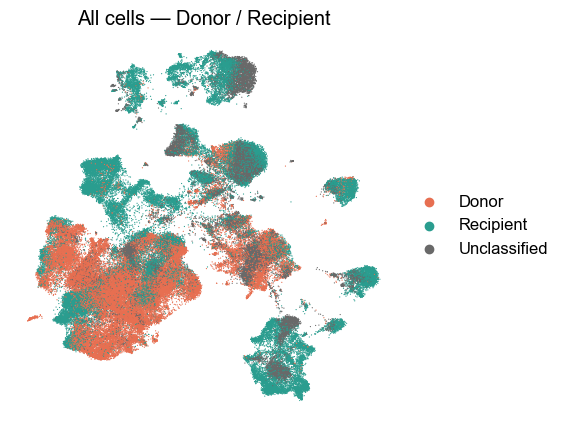

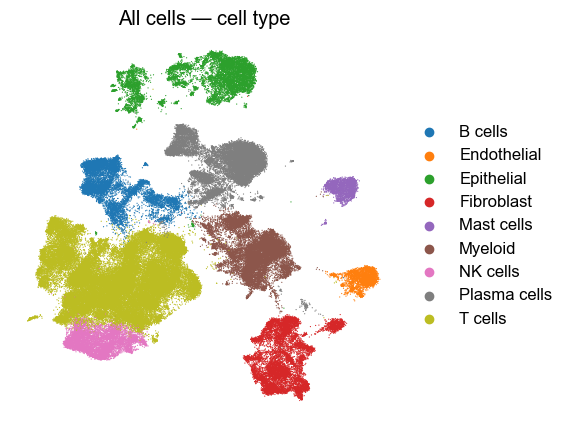

In [10]:
mpl.rcParams.update({'font.size':12,'svg.fonttype':'none',
                     'font.family':'Arial','figure.figsize':(5,5)})

PALETTE = {'Donor':'#e76f51','Recipient':'#2a9d8f',
           'Ambiguous':'#f4a261','Unclassified':'dimgray'}

if 'X_umap' in adata_all.obsm:
    adata_all.obs['sample_type'] = adata_all.obs['sample_type'].astype('category')
    sc.pl.umap(adata_all, color='sample_type', palette=PALETTE,
               s=3, frameon=False, title='All cells — Donor / Recipient', show=False)
    plt.savefig(FIGURES_SC_DIR/'umap_all_cells_donor_recipient.pdf',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(FIGURES_SC_DIR/'umap_all_cells_donor_recipient.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    sc.pl.umap(adata_all, color='cell_type', s=3, frameon=False,
               title='All cells — cell type', show=True)
else:
    print('No UMAP in adata_all')

## Save

## Per-sample diagnostic UMAPs

For every sample, plot 4 panels on the sample's own UMAP coordinates:
1. **Freemuxlet group** — SNG-0 vs SNG-1 vs Unclassified
2. **Cell type** — annotated cell types
3. **TCR clone** — MLR-mapped donor clone vs not (T cells only; other cells shown as grey)
4. **Inferred sex** — per-cell sex from DDX3Y / EIF1AY / XIST (sex-mismatched patients only)

In [11]:
# ── Pre-compute per-cell TCR mapping and inferred sex on adata_all ────────────
# TCR mapping: Mapped / Not_mapped / Non-T_cell
tcr_status = pd.Series('Non-T_cell', index=adata_all.obs_names)
tcells_idx = adata_all.obs_names[adata_all.obs['cell_type'] == 'T cells']
tcr_status.loc[tcells_idx] = 'Not_mapped'
mapped_barcodes = set(mapped_obs.index)
mapped_in_all = [bc for bc in tcells_idx if bc in mapped_barcodes]
tcr_status.loc[mapped_in_all] = 'Mapped'
adata_all.obs['tcr_status'] = tcr_status.values

# Inferred sex (all cells)
layer = tcell_ann_concat.layers.get('counts', tcell_ann_concat.X)
expr_all = layer.toarray() if sp.issparse(layer) else np.array(layer)
# Re-index to adata_all order (some cells may be missing after join='outer')
obs_order = adata_all.obs_names
orig_order = tcell_ann_concat.obs_names
orig_idx_map = pd.Series(range(len(orig_order)), index=orig_order)
row_indices = orig_idx_map.reindex(obs_order).values

y_mean_all = np.full(len(adata_all), np.nan)
x_val_all  = np.full(len(adata_all), np.nan)
valid = ~np.isnan(row_indices)
valid_rows = row_indices[valid].astype(int)
if y_idx:
    y_mean_all[valid] = expr_all[valid_rows][:, y_idx].mean(axis=1)
if x_gene_present:
    x_val_all[valid] = expr_all[valid_rows, x_idx]

inferred_sex = pd.Series('Unknown', index=adata_all.obs_names)
inferred_sex[(y_mean_all > Y_MALE_THRESHOLD)   & (x_val_all < X_MALE_THRESHOLD)]   = 'Male'
inferred_sex[(y_mean_all < Y_FEMALE_THRESHOLD) & (x_val_all > X_FEMALE_THRESHOLD)] = 'Female'
adata_all.obs['inferred_sex'] = inferred_sex.values

print('TCR status distribution:')
print(adata_all.obs['tcr_status'].value_counts().to_string())
print('\nInferred sex distribution:')
print(adata_all.obs['inferred_sex'].value_counts().to_string())

TCR status distribution:
tcr_status
Non-T_cell    65902
Not_mapped    46047
Mapped         1106

Inferred sex distribution:
inferred_sex
Unknown    55067
Male       43449
Female     14539


In [12]:
# ── Per-sample 4-panel UMAP ───────────────────────────────────────────────────
PER_SAMPLE_DIR = FIGURES_SC_DIR / 'per_sample_umaps'
PER_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.size': 9, 'svg.fonttype': 'none',
    'font.family': 'Arial', 'axes.titlesize': 10,
})

GRP_PALETTE = {'0': '#4e9af1', '1': '#f4845f', 'Unclassified': 'lightgray'}
TCR_PALETTE = {'Mapped': '#c0392b', 'Not_mapped': '#bdc3c7', 'Non-T_cell': '#ecf0f1'}
SEX_PALETTE = {'Male': '#3498db', 'Female': '#e91e8c', 'Unknown': '#e0e0e0'}

samples_to_plot = sorted(adata_all.obs['SampleID'].unique())

for sample in samples_to_plot:
    s = adata_all[adata_all.obs['SampleID'] == sample].copy()
    if 'X_umap' not in s.obsm:
        print(f'{sample}: no UMAP, skipping')
        continue

    n_cells    = len(s)
    dot_size   = max(2, min(20, 3000 / n_cells))
    row        = results_df[results_df['SampleID'] == sample].iloc[0]
    method_str = f"Method: {row['method_used']}  |  {row['final_label']}"

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'{sample}  ({n_cells} cells)  —  {method_str}', fontsize=10, fontweight='bold')
    umap_coords = s.obsm['X_umap']

    # Panel 1: Freemuxlet group
    ax  = axes[0]
    grp = s.obs['freemux_group'].astype(str).replace('nan', 'Unclassified')
    for label, color in [('0', GRP_PALETTE['0']), ('1', GRP_PALETTE['1']),
                          ('Unclassified', GRP_PALETTE['Unclassified'])]:
        mask = (grp == label).values
        if mask.any():
            ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
                       c=color, s=dot_size, alpha=0.7, linewidths=0,
                       label=f'SNG-{label}' if label != 'Unclassified' else label,
                       rasterized=True)
    ax.set_title('Freemuxlet group')
    ax.axis('off')
    ax.legend(markerscale=2, frameon=False, loc='lower left', fontsize=7)

    # Panel 2: Cell type
    ax         = axes[1]
    cell_types = s.obs['cell_type'].astype(str)
    unique_ct  = sorted(cell_types.unique())
    colors20   = [plt.cm.tab20(i / 20) for i in range(20)]
    ct_colors  = {ct: colors20[i % 20] for i, ct in enumerate(unique_ct)}
    for ct in unique_ct:
        mask = (cell_types == ct).values
        ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
                   c=[ct_colors[ct]], s=dot_size, alpha=0.7, linewidths=0,
                   label=ct, rasterized=True)
    ax.set_title('Cell type')
    ax.axis('off')
    ax.legend(markerscale=2, frameon=False, loc='lower left', fontsize=6,
              ncol=1 + len(unique_ct) // 8)

    # Panel 3: TCR clone mapping
    ax  = axes[2]
    tcr = s.obs['tcr_status'].astype(str)
    for label, color, zo, al in [('Non-T_cell', TCR_PALETTE['Non-T_cell'], 1, 0.4),
                                   ('Not_mapped',  TCR_PALETTE['Not_mapped'],  2, 0.6),
                                   ('Mapped',      TCR_PALETTE['Mapped'],      3, 0.9)]:
        mask = (tcr == label).values
        if mask.any():
            ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
                       c=color, s=dot_size if label != 'Mapped' else dot_size * 1.5,
                       alpha=al, linewidths=0, label=label, rasterized=True, zorder=zo)
    n_mapped = (tcr == 'Mapped').sum()
    ax.set_title(f'TCR donor clones  (n={n_mapped} mapped)')
    ax.axis('off')
    ax.legend(markerscale=2, frameon=False, loc='lower left', fontsize=7)

    # Panel 4: Inferred sex
    ax  = axes[3]
    sex = s.obs['inferred_sex'].astype(str)
    if sample in SEX_MISMATCHED_PATIENTS:
        rs = SEX_MAP[sample]['recipient']
        ds = SEX_MAP[sample]['donor']
        title_suffix = f'(Rec={rs[0]}, Don={ds[0]})'
    else:
        title_suffix = '(sex-matched / unknown)'
    for label, color in [('Unknown', SEX_PALETTE['Unknown']),
                          ('Male',    SEX_PALETTE['Male']),
                          ('Female',  SEX_PALETTE['Female'])]:
        mask = (sex == label).values
        if mask.any():
            ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
                       c=color, s=dot_size, alpha=0.7, linewidths=0,
                       label=label, rasterized=True)
    ax.set_title(f'Inferred sex  {title_suffix}')
    ax.axis('off')
    ax.legend(markerscale=2, frameon=False, loc='lower left', fontsize=7)

    plt.tight_layout()
    out_png = PER_SAMPLE_DIR / f'{sample}_diagnostic_umap.png'
    out_pdf = PER_SAMPLE_DIR / f'{sample}_diagnostic_umap.pdf'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.savefig(out_pdf, dpi=150, bbox_inches='tight', transparent=True)
    plt.close()

print(f'Saved {len(samples_to_plot)} per-sample UMAPs to:\n{PER_SAMPLE_DIR}')

Saved 48 per-sample UMAPs to:
../../Figures/Single_cell_figures/per_sample_umaps


In [13]:
adata_all.write_h5ad(OUT_ADATA_PATH)
print(f'Saved {adata_all.shape} -> {OUT_ADATA_PATH}')
print('\nsample_type:')
print(adata_all.obs['sample_type'].value_counts())
print('\nPer-sample methods:')
print(results_df[['SampleID','method_used','final_label','n_methods_ok','agreement']].to_string(index=False))

Saved (113055, 38012) -> ../../adata_file/all_cells_donor_recipient_celltype.h5ad

sample_type:
sample_type
Recipient       47850
Donor           47298
Unclassified    17907
Name: count, dtype: int64

Per-sample methods:
SampleID method_used                  final_label  n_methods_ok agreement
    RH01    CellType SNG-0=Donor, SNG-1=Recipient             1    single
    RH02    CellType SNG-0=Donor, SNG-1=Recipient             1    single
    RH03    CellType SNG-0=Donor, SNG-1=Recipient             1    single
    RH04    CellType SNG-0=Recipient, SNG-1=Donor             1    single
    RH05    CellType SNG-0=Recipient, SNG-1=Donor             1    single
    RH06    CellType SNG-0=Recipient, SNG-1=Donor             1    single
    RH07         Sex SNG-0=Donor, SNG-1=Recipient             2     agree
    RH08         Sex SNG-0=Recipient, SNG-1=Donor             2     agree
    RH09         Sex SNG-0=Recipient, SNG-1=Donor             2     agree
    RH10         Sex SNG-0=Recipient, S

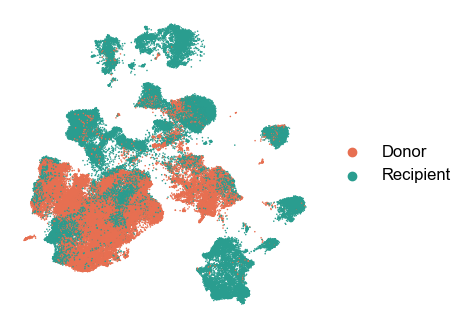

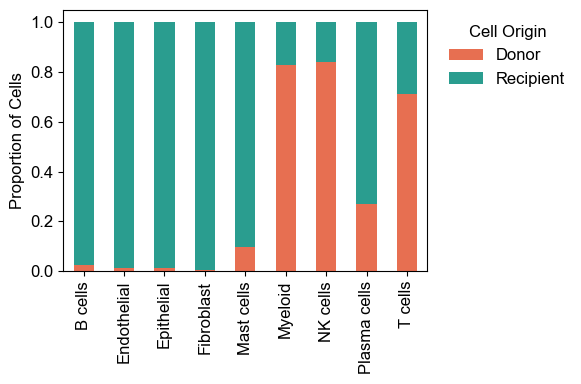

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'font.size': 12,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (4, 4)
})
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

# Use in-memory adata_all — exclude Unclassified cells
adata_dr = adata_all[(adata_all.obs['sample_type'] != 'Unclassified')].copy()

# ── Figure 1: UMAP coloured by sample_type ─────────────────────────────────
sc.pl.umap(adata_dr, color='sample_type', s=5, frameon=False, show=False, title='')
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300_dr_all_cells.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300_dr_all_cells.png', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300_dr_all_cells.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# ── Figure 2: Stacked barplot — cell origin by cell type ───────────────────
mpl.rcParams['figure.figsize'] = (6, 4)

adata_classified = adata_dr

color_palette = {'Donor': '#e76f51', 'Recipient': '#2a9d8f', 'Unclassified': 'dimgray'}
cluster_origin_counts      = pd.crosstab(adata_classified.obs['cell_type'], adata_classified.obs['sample_type'])
cluster_origin_counts_norm = cluster_origin_counts.div(cluster_origin_counts.sum(axis=1), axis=0)
colors = [color_palette.get(col, 'gray') for col in cluster_origin_counts_norm.columns]

cluster_origin_counts_norm.plot(kind='bar', stacked=True, color=colors)
plt.xlabel('')
plt.ylabel('Proportion of Cells')
plt.legend(title='Cell Origin', frameon=False, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_cluster_dr_all_cells.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_cluster_dr_all_cells.png', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_cluster_dr_all_cells.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [15]:
# ── Annotation rate: all cells ────────────────────────────────────────────
r096_all = adata_all.obs['SampleID'].isin(['R096_Tc17_low', 'R096_Tc17_up'])
eligible_all = adata_all[~r096_all]
annotated_all = eligible_all[eligible_all.obs['sample_type'].isin(['Donor', 'Recipient'])]
pct_all = len(annotated_all) / len(eligible_all) * 100
print(f"Total all cells (excl. R096): {len(eligible_all)}")
print(f"Annotated (Donor + Recipient): {len(annotated_all)}")
print(f"Annotation rate: {pct_all:.1f}%")

Total all cells (excl. R096): 113055
Annotated (Donor + Recipient): 95148
Annotation rate: 84.2%


In [16]:
# ── T cell figures: UMAP + barplot using T cell UMAP coordinates ───────────
TCELL_ANN_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_Tcell_only_Migration.h5ad'

# Load T cell adata (has own UMAP + T_cell_subsets)
tcell_adata = anndata.read_h5ad(TCELL_ANN_PATH)

# Transfer sample_type and method_used from in-memory adata_all
tcell_adata.obs['sample_type'] = adata_all.obs['sample_type'].reindex(tcell_adata.obs_names)
tcell_adata.obs['method_used'] = adata_all.obs['method_used'].reindex(tcell_adata.obs_names)
# After loading tcell_adata (before filtering R096)
r096 = tcell_adata.obs['SampleID'].isin(['R096_Tc17_low', 'R096_Tc17_up'])
eligible = tcell_adata[~r096]
annotated = eligible[eligible.obs['sample_type'].isin(['Donor', 'Recipient'])]
pct = len(annotated) / len(eligible) * 100
print(f"Total T cells (excl. R096): {len(eligible)}")
print(f"Annotated (Donor + Recipient): {len(annotated)}")
print(f"Annotation rate: {pct:.1f}%")


Total T cells (excl. R096): 35630
Annotated (Donor + Recipient): 33546
Annotation rate: 94.2%


Saved (38539, 38012) -> ../../adata_file/tcell_ann_concat_con_muxlet.h5ad
T cells after filtering: (33546, 38012)
sample_type
Donor        23993
Recipient     9553
Name: count, dtype: int64


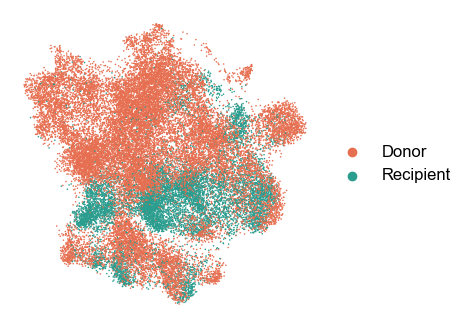

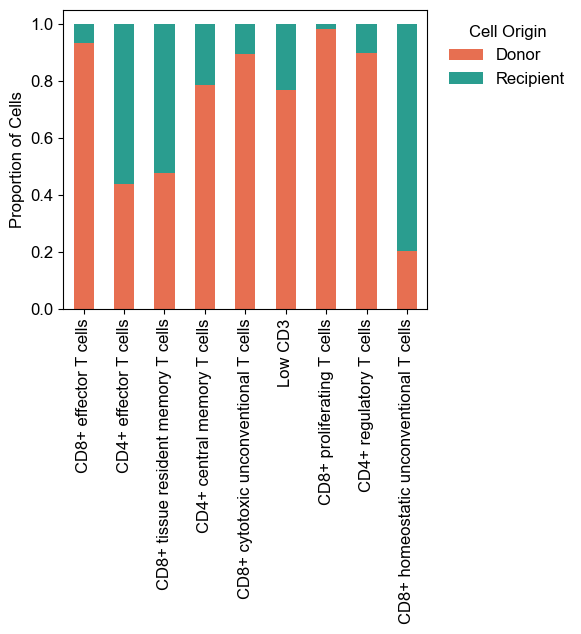

In [17]:
# Remove Unclassified, Normal Donor, and R096 samples (no freemuxlet output)
tcell_adata.write_h5ad(OUT_TCELL_ADATA_PATH)
print(f'Saved {tcell_adata.shape} -> {OUT_TCELL_ADATA_PATH}')

tcell_adata = tcell_adata[
    (tcell_adata.obs['sample_type'] != 'Unclassified') &
    #(tcell_adata.obs['method_used'] != 'ND') &
    (~tcell_adata.obs['SampleID'].isin(['R096_Tc17_low', 'R096_Tc17_up'])) # no freemuxlet output for R096 samples
].copy()

# Set consistent colors: Donor=#e76f51, Recipient=#2a9d8f
import pandas as pd
tcell_adata.obs['sample_type'] = tcell_adata.obs['sample_type'].astype(
    pd.CategoricalDtype(categories=['Donor', 'Recipient'], ordered=False))
tcell_adata.uns['sample_type_colors'] = ['#e76f51', '#2a9d8f']

print('T cells after filtering:', tcell_adata.shape)
print(tcell_adata.obs['sample_type'].value_counts())

mpl.rcParams.update({
    'font.size': 12,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (4, 4)
})
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

# ── Figure 3: T cell UMAP coloured by sample_type ──────────────────────────
sc.pl.umap(tcell_adata, color='sample_type', s=5, frameon=False, show=False, title='')
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300_dr.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300_dr.png', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'umap_clusters_dpi300_dr.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# ── Figure 4: Stacked barplot — cell origin by T_cell_subsets ──────────────
mpl.rcParams['figure.figsize'] = (6, 6.5)

color_palette = {'Donor': '#e76f51', 'Recipient': '#2a9d8f'}
cluster_origin_counts      = pd.crosstab(tcell_adata.obs['T_cell_subsets'], tcell_adata.obs['sample_type'])
cluster_origin_counts_norm = cluster_origin_counts.div(cluster_origin_counts.sum(axis=1), axis=0)
colors = [color_palette.get(col, 'gray') for col in cluster_origin_counts_norm.columns]

cluster_origin_counts_norm.plot(kind='bar', stacked=True, color=colors)
plt.xlabel('')
plt.ylabel('Proportion of Cells')
plt.legend(title='Cell Origin', frameon=False, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_cluster_dr.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_cluster_dr.png', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_cluster_dr.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

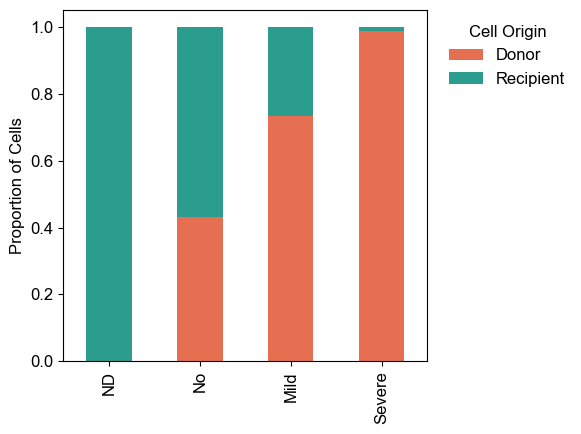

In [21]:
# ── Figure 4: Stacked barplot — cell origin by GVHD grade (ordered) ──────────
mpl.rcParams['figure.figsize'] = (6, 4.5)

# Ensure GVHD grade categories are ordered as: ND, No, Mild, Severe
categories_order = ['ND', 'No', 'Mild', 'Severe']
if 'GVHD_Grade_1' in tcell_adata.obs.columns:
    tcell_adata.obs['GVHD_Grade_1'] = tcell_adata.obs['GVHD_Grade_1'].astype(pd.CategoricalDtype(categories=categories_order, ordered=True))
else:
    # If the column is missing, create an ND (no data) column so plotting doesn't fail
    tcell_adata.obs['GVHD_Grade_1'] = pd.Categorical(['ND'] * len(tcell_adata), categories=categories_order, ordered=True)

color_palette = {'Donor': '#e76f51', 'Recipient': '#2a9d8f'}
cluster_origin_counts = pd.crosstab(tcell_adata.obs['GVHD_Grade_1'], tcell_adata.obs['sample_type'])
# Reindex rows to the explicit category order to guarantee plotting order
cluster_origin_counts = cluster_origin_counts.reindex(categories_order).fillna(0)
cluster_origin_counts_norm = cluster_origin_counts.div(cluster_origin_counts.sum(axis=1).replace(0, 1), axis=0)
colors = [color_palette.get(col, 'gray') for col in cluster_origin_counts_norm.columns]

cluster_origin_counts_norm.plot(kind='bar', stacked=True, color=colors)
plt.xlabel('')
plt.ylabel('Proportion of Cells')
plt.legend(title='Cell Origin', frameon=False, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_grade_dr.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_grade_dr.png', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'barplot_cell_origin_by_grade_dr.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()